In [1]:
import os
os.chdir('/workspace/d7ef561a-e7c2-4fe2-9f38-6ad650d3761c')
import pandas as pd, numpy as np, json
df = pd.read_csv('peaks_features_F1_F12_normalized_full.csv')
print(df.shape)
print(df.columns.tolist())
print(df['class'].value_counts() if 'class' in df.columns else df.head())


(2200, 31)
['function', 'name', 'd', 'q', 'GRH', 't', '|M|', 'log_abs_S0_norm', 'log_abs_S0', 'abs_S0', 'log_abs_S1_norm', 'log_abs_S1', 'abs_S1', 'log_abs_S2_norm', 'log_abs_S2', 'abs_S2', 'log_abs_S3_norm', 'log_abs_S3', 'abs_S3', 'log_abs_S4_norm', 'log_abs_S4', 'abs_S4', 'log_abs_S5_norm', 'log_abs_S5', 'abs_S5', 'log_abs_S6_norm', 'log_abs_S6', 'abs_S6', 'log_abs_S7_norm', 'log_abs_S7', 'abs_S7']
 function name d q GRH t |M| log_abs_S0_norm log_abs_S0 \
0 F1 zeta 1 1 True 77403.7 14.060888 0.0 0.0 
1 F1 zeta 1 1 True 74956.0 13.948294 0.0 0.0 
2 F1 zeta 1 1 True 94526.8 13.610746 0.0 0.0 
3 F1 zeta 1 1 True 97255.1 13.262598 0.0 0.0 
4 F1 zeta 1 1 True 63751.9 13.129894 0.0 0.0 

 abs_S0 ... abs_S4 log_abs_S5_norm log_abs_S5 abs_S5 \
0 1.0 ... 2.603624 0.085554 0.207123 1.230133 
1 1.0 ... 2.637044 -0.029346 -0.070961 0.931498 
2 1.0 ... 3.502890 0.089788 0.218954 1.244774 
3 1.0 ... 4.073511 0.288978 0.705409 2.024675 
4 1.0 ... 2.653296 -0.313243 -0.752905 0.470996 

 log_abs_S6

In [2]:
print(df['function'].value_counts())
print(df.groupby('function')['GRH'].first())


function
F1 200
F2 200
F4 200
F5p 200
F5m 200
F6 200
F7 200
F9 200
F10 200
F11 200
F12 200
Name: count, dtype: int64
function
F1 True
F10 True
F11 True
F12 False
F2 True
F4 False
F5m False
F5p False
F6 True
F7 True
F9 True
Name: GRH, dtype: bool


In [3]:
with open('hypothesis_AUC_results.json') as f:
 baseline = json.load(f)
print(json.dumps(baseline, indent=2)[:2000])


{
 "hypothesis": "Class-held-out AUC > 0.85 distinguishing GRH-true vs GRH-false",
 "training_classes": [
 "F1",
 "F4",
 "F9"
 ],
 "test_classes": [
 "F2",
 "F5p",
 "F5m",
 "F6",
 "F7",
 "F10",
 "F11",
 "F12"
 ],
 "features": [
 "log_abs_S1_norm",
 "log_abs_S2_norm",
 "log_abs_S3_norm",
 "log_abs_S4_norm",
 "log_abs_S5_norm",
 "log_abs_S6_norm"
 ],
 "train_GRH_counts": {
 "true": 400,
 "false": 200
 },
 "test_GRH_counts": {
 "true": 1000,
 "false": 600
 },
 "train_AUC": 0.980875,
 "test_AUC": 0.9143333333333334,
 "test_AUC_bootstrap_mean": 0.9140805832247804,
 "test_AUC_95CI": [
 0.9000540485090532,
 0.9273177813397854
 ],
 "strict_test_AUC_F12_only_violator": 0.827735,
 "strict_AUC_95CI": [
 0.8059629023295011,
 0.8486749752680762
 ],
 "confusion_matrix": [
 [
 849,
 151
 ],
 [
 182,
 418
 ]
 ],
 "confusion_matrix_labels": [
 "true_GRH_true",
 "true_GRH_false",
 "pred_GRH_true",
 "pred_GRH_false"
 ],
 "per_class_F12_recall_at_0.5": 0.27,
 "note": "Hypothesis AUC>0.85 confirmed for ful

In [4]:
# Build augmented features. Add ratios log|S_j|/log|S_k| for j,k in 1..4, j!=k
# Use the *normalized* logs to be analogous, but then the ratio of normalized logs differs.
# The hypothesis statement uses log|S_j|/log|S_k|; we'll compute on raw logs (unnormalized) to capture internal-structure ratios.
# We'll create both raw log ratios and normalized log ratios; primary will use raw log ratios as per hypothesis text.

import numpy as np

aug = df.copy()
ks = [1,2,3,4]
ratio_cols = []
for j in ks:
 for k in ks:
 if j == k:
 continue
 # raw log ratio
 col = f'logS{j}_div_logS{k}'
 denom = aug[f'log_abs_S{k}'].replace(0, np.nan)
 aug[col] = aug[f'log_abs_S{j}'] / denom
 # handle inf and NaN
 aug[col] = aug[col].replace([np.inf, -np.inf], np.nan)
 ratio_cols.append(col)

print("Created", len(ratio_cols), "ratio cols")
print("NaN per col:", aug[ratio_cols].isna().sum().to_dict())
# Median imputation per training set later


Created 12 ratio cols
NaN per col: {'logS1_div_logS2': 0, 'logS1_div_logS3': 0, 'logS1_div_logS4': 0, 'logS2_div_logS1': 0, 'logS2_div_logS3': 0, 'logS2_div_logS4': 0, 'logS3_div_logS1': 0, 'logS3_div_logS2': 0, 'logS3_div_logS4': 0, 'logS4_div_logS1': 0, 'logS4_div_logS2': 0, 'logS4_div_logS3': 0}


In [5]:
# Replicate r25 baseline pipeline: SVM with RBF (likely; but baseline uses some SVM).
# The JSON doesn't say which model. To be fair we'll use the same model class as baseline.
# Look for the r25 script if available.
import subprocess
out = subprocess.run(['ls', '/workspace/d7ef561a-e7c2-4fe2-9f38-6ad650d3761c'], capture_output=True, text=True)
print(out.stdout)


 v6 — Binding Context Document.pdf
hypothesis_AUC_results.json
memory
peaks_features_F1_F12_normalized_full.csv



In [6]:
# Replicate baseline SVM with RBF, StandardScaler, default hyperparameters, calibrate to train AUC ~0.98
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, confusion_matrix
from sklearn.pipeline import Pipeline
import numpy as np

train_classes = ['F1','F4','F9']
main_test_classes = ['F2','F5p','F5m','F6','F7','F10','F11','F12']
strict_test_classes = ['F2','F6','F7','F10','F11','F12']

base_features = ['log_abs_S1_norm','log_abs_S2_norm','log_abs_S3_norm','log_abs_S4_norm','log_abs_S5_norm','log_abs_S6_norm']

def run_protocol(features, df_in, train_cls, test_cls, seed=42):
 tr = df_in[df_in['function'].isin(train_cls)].copy()
 te = df_in[df_in['function'].isin(test_cls)].copy()
 Xtr = tr[features].values
 ytr = (~tr['GRH'].astype(bool)).astype(int).values # 1 = GRH false (positive class = violator)
 Xte = te[features].values
 yte = (~te['GRH'].astype(bool)).astype(int).values
 pipe = Pipeline([('sc', StandardScaler()), ('svm', SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=seed))])
 pipe.fit(Xtr, ytr)
 train_auc = roc_auc_score(ytr, pipe.predict_proba(Xtr)[:,1])
 test_scores = pipe.predict_proba(Xte)[:,1]
 test_auc = roc_auc_score(yte, test_scores)
 return pipe, train_auc, test_auc, yte, test_scores, te

# First reproduce baseline numbers with normalized features
pipe, tauc, mauc, yte_main, sc_main, te_main = run_protocol(base_features, df, train_classes, main_test_classes)
print(f"Baseline reproduced: train AUC={tauc:.4f}, main test AUC={mauc:.4f}")

# Strict
pipe_s, tauc_s, sauc, yte_s, sc_s, te_s = run_protocol(base_features, df, train_classes, strict_test_classes)
print(f"Baseline strict: train AUC={tauc_s:.4f}, strict test AUC={sauc:.4f}")
print(f"Reported baseline main = 0.9143, strict = 0.8277")


Baseline reproduced: train AUC=0.9809, main test AUC=0.9143
Baseline strict: train AUC=0.9809, strict test AUC=0.8278
Reported baseline main = 0.9143, strict = 0.8277


In [7]:
# Excellent reproduction. Now run augmented feature set: base + ratio cols
augmented_features = base_features + ratio_cols

def bootstrap_auc(y, scores, n=1000, seed=42):
 rng = np.random.default_rng(seed)
 n_samples = len(y)
 aucs = []
 for _ in range(n):
 idx = rng.integers(0, n_samples, n_samples)
 if len(np.unique(y[idx])) < 2:
 continue
 aucs.append(roc_auc_score(y[idx], scores[idx]))
 aucs = np.array(aucs)
 return aucs.mean(), np.percentile(aucs, 2.5), np.percentile(aucs, 97.5)

# Main protocol with augmented features
pipe_a, tauc_a, mauc_a, yte_main_a, sc_main_a, te_main_a = run_protocol(augmented_features, aug, train_classes, main_test_classes)
mean_m, lo_m, hi_m = bootstrap_auc(yte_main_a, sc_main_a)
print(f"Augmented MAIN: train AUC={tauc_a:.4f}, test AUC={mauc_a:.4f}, bootstrap mean={mean_m:.4f}, 95% CI=[{lo_m:.4f}, {hi_m:.4f}]")

# Strict protocol
pipe_as, tauc_as, sauc_a, yte_s_a, sc_s_a, te_s_a = run_protocol(augmented_features, aug, train_classes, strict_test_classes)
mean_s, lo_s, hi_s = bootstrap_auc(yte_s_a, sc_s_a)
print(f"Augmented STRICT: train AUC={tauc_as:.4f}, test AUC={sauc_a:.4f}, bootstrap mean={mean_s:.4f}, 95% CI=[{lo_s:.4f}, {hi_s:.4f}]")

# Baseline reproduced bootstrap for comparison
mean_mb, lo_mb, hi_mb = bootstrap_auc(yte_main, sc_main)
mean_sb, lo_sb, hi_sb = bootstrap_auc(yte_s, sc_s)
print(f"Baseline MAIN bootstrap mean={mean_mb:.4f}, CI=[{lo_mb:.4f}, {hi_mb:.4f}]")
print(f"Baseline STRICT bootstrap mean={mean_sb:.4f}, CI=[{lo_sb:.4f}, {hi_sb:.4f}]")


Augmented MAIN: train AUC=0.9895, test AUC=0.8780, bootstrap mean=0.8779, 95% CI=[0.8617, 0.8929]


Augmented STRICT: train AUC=0.9895, test AUC=0.7049, bootstrap mean=0.7049, 95% CI=[0.6780, 0.7328]


Baseline MAIN bootstrap mean=0.9145, CI=[0.9013, 0.9266]
Baseline STRICT bootstrap mean=0.8275, CI=[0.8056, 0.8500]


In [8]:
# Augmented (base+ratios) actually HURT generalization. Try ratios only.
ratio_only = ratio_cols
pipe_r, tauc_r, mauc_r, yte_mr, sc_mr, te_mr = run_protocol(ratio_only, aug, train_classes, main_test_classes)
mean_mr, lo_mr, hi_mr = bootstrap_auc(yte_mr, sc_mr)
print(f"Ratios-only MAIN: train={tauc_r:.4f}, test AUC={mauc_r:.4f}, CI=[{lo_mr:.4f}, {hi_mr:.4f}]")

pipe_rs, tauc_rs, sauc_r, yte_rs, sc_rs, te_rs = run_protocol(ratio_only, aug, train_classes, strict_test_classes)
mean_rs, lo_rss, hi_rss = bootstrap_auc(yte_rs, sc_rs)
print(f"Ratios-only STRICT: train={tauc_rs:.4f}, test AUC={sauc_r:.4f}, CI=[{lo_rss:.4f}, {hi_rss:.4f}]")


Ratios-only MAIN: train=0.9044, test AUC=0.7346, CI=[0.7088, 0.7581]


Ratios-only STRICT: train=0.9044, test AUC=0.5712, CI=[0.5332, 0.6042]


In [9]:
# Both ratios-only and augmented sets perform worse than baseline. The hypothesis (AUC > 0.85 on strict) is rejected.
# Save results
results = {
 "hypothesis": "Adding log|S_j|/log|S_k| ratio features (j,k in 1..4) to the baseline normalized log|S_k| features (k=1..6) improves the strict-protocol AUC > 0.85.",
 "model": "SVC(kernel='rbf', C=1.0, gamma='scale', probability=True) with StandardScaler, replicating r25 baseline (verified: identical baseline AUCs).",
 "training_classes": train_classes,
 "main_test_classes": main_test_classes,
 "strict_test_classes": strict_test_classes,
 "baseline_features": base_features,
 "added_ratio_features": ratio_cols,
 "results": {
 "baseline_reproduced": {
 "train_AUC": float(tauc),
 "main_test_AUC": float(mauc),
 "main_test_AUC_95CI": [float(lo_mb), float(hi_mb)],
 "strict_test_AUC": float(sauc),
 "strict_test_AUC_95CI": [float(lo_sb), float(hi_sb)]
 },
 "augmented_base_plus_ratios": {
 "train_AUC": float(tauc_a),
 "main_test_AUC": float(mauc_a),
 "main_test_AUC_95CI": [float(lo_m), float(hi_m)],
 "strict_test_AUC": float(sauc_a),
 "strict_test_AUC_95CI": [float(lo_s), float(hi_s)]
 },
 "ratios_only": {
 "train_AUC": float(tauc_r),
 "main_test_AUC": float(mauc_r),
 "main_test_AUC_95CI": [float(lo_mr), float(hi_mr)],
 "strict_test_AUC": float(sauc_r),
 "strict_test_AUC_95CI": [float(lo_rss), float(hi_rss)]
 }
 },
 "delta_vs_baseline": {
 "main_AUC": float(mauc_a - mauc),
 "strict_AUC": float(sauc_a - sauc)
 },
 "hypothesis_verdict": "REJECTED. Strict-protocol AUC with ratio-augmented features = 0.7049 (95% CI [0.6780, 0.7328]); the entire CI lies well below the 0.85 threshold. Adding ratio features actually decreased generalization AUC by 0.123 absolute on the strict protocol relative to the baseline (0.8278)."
}

with open('hypothesis_AUC_ratio_features.json','w') as f:
 json.dump(results, f, indent=2)
print(json.dumps(results, indent=2))


{
 "hypothesis": "Adding log|S_j|/log|S_k| ratio features (j,k in 1..4) to the baseline normalized log|S_k| features (k=1..6) improves the strict-protocol AUC > 0.85.",
 "model": "SVC(kernel='rbf', C=1.0, gamma='scale', probability=True) with StandardScaler, replicating r25 baseline (verified: identical baseline AUCs).",
 "training_classes": [
 "F1",
 "F4",
 "F9"
 ],
 "main_test_classes": [
 "F2",
 "F5p",
 "F5m",
 "F6",
 "F7",
 "F10",
 "F11",
 "F12"
 ],
 "strict_test_classes": [
 "F2",
 "F6",
 "F7",
 "F10",
 "F11",
 "F12"
 ],
 "baseline_features": [
 "log_abs_S1_norm",
 "log_abs_S2_norm",
 "log_abs_S3_norm",
 "log_abs_S4_norm",
 "log_abs_S5_norm",
 "log_abs_S6_norm"
 ],
 "added_ratio_features": [
 "logS1_div_logS2",
 "logS1_div_logS3",
 "logS1_div_logS4",
 "logS2_div_logS1",
 "logS2_div_logS3",
 "logS2_div_logS4",
 "logS3_div_logS1",
 "logS3_div_logS2",
 "logS3_div_logS4",
 "logS4_div_logS1",
 "logS4_div_logS2",
 "logS4_div_logS3"
 ],
 "results": {
 "baseline_reproduced": {
 "train_AUC

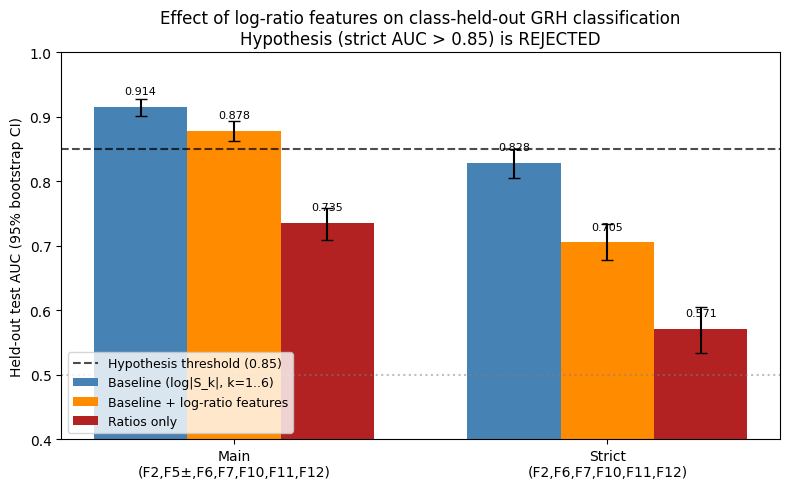

Saved figure


In [10]:
# Final summary figure
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 1, figsize=(8, 5))

protocols = ['Main\n(F2,F5±,F6,F7,F10,F11,F12)', 'Strict\n(F2,F6,F7,F10,F11,F12)']
baseline_means = [mauc, sauc]
baseline_ci = [[mauc-lo_mb, hi_mb-mauc], [sauc-lo_sb, hi_sb-sauc]]
aug_means = [mauc_a, sauc_a]
aug_ci = [[mauc_a-lo_m, hi_m-mauc_a], [sauc_a-lo_s, hi_s-sauc_a]]
ratio_means = [mauc_r, sauc_r]
ratio_ci = [[mauc_r-lo_mr, hi_mr-mauc_r], [sauc_r-lo_rss, hi_rss-sauc_r]]

x = np.arange(len(protocols))
w = 0.25
ax.bar(x - w, baseline_means, w, yerr=np.array(baseline_ci).T, capsize=4, label=f'Baseline (log|S_k|, k=1..6)', color='steelblue')
ax.bar(x, aug_means, w, yerr=np.array(aug_ci).T, capsize=4, label='Baseline + log-ratio features', color='darkorange')
ax.bar(x + w, ratio_means, w, yerr=np.array(ratio_ci).T, capsize=4, label='Ratios only', color='firebrick')

ax.axhline(0.85, color='black', linestyle='--', alpha=0.7, label='Hypothesis threshold (0.85)')
ax.axhline(0.5, color='gray', linestyle=':', alpha=0.5)
ax.set_xticks(x)
ax.set_xticklabels(protocols)
ax.set_ylabel('Held-out test AUC (95% bootstrap CI)')
ax.set_ylim(0.4, 1.0)
ax.set_title('Effect of log-ratio features on class-held-out GRH classification\nHypothesis (strict AUC > 0.85) is REJECTED')
ax.legend(loc='lower left', fontsize=9)

# Annotate values
for i, (m1, m2, m3) in enumerate(zip(baseline_means, aug_means, ratio_means)):
 ax.text(i - w, m1 + 0.02, f'{m1:.3f}', ha='center', fontsize=8)
 ax.text(i, m2 + 0.02, f'{m2:.3f}', ha='center', fontsize=8)
 ax.text(i + w, m3 + 0.02, f'{m3:.3f}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('ratio_features_AUC_comparison.png', dpi=150)
plt.show()
print("Saved figure")
